In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/clarra/dataset-all-split/dataset_with_split.csv


# M2-v2 — CABiLSTM-IndoBERT (Partial Unfreeze, Multilabel Wide Format)

**CABiLSTM-BERT (He et al., 2025) with partial BERT fine-tuning for Indonesian multilabel ABSA.**

## Architecture:
```
Input: [CLS] review_text [SEP]
  │
  ▼
IndoBERT ──────────────────────► V  [B, L, 768]
  ├─ Layers 0–7  : FROZEN
  └─ Layers 8–11 : TRAINABLE (lr=2e-5)
  │
  ▼
CABiLSTM (lr=5e-4)
  ├─ BiLSTM L1 ──────────────► F1, B1
  ├─ BiLSTM L2 ──────────────► F2, B2
  ├─ MHSA × 5 groups ────────► A1..A5
  └─ Conv2d (5→1) + ReLU ────► Co  [B, L, 768]
  │
  ▼
Masked Mean Pooling ────────────► M  [B, 768]
  │
  ▼
MLP: 1024 → 512 → 15 outputs
```

## Key differences from M2 (Frozen):
| Component | M2 | M2-v2 |
|---|---|---|
| BERT layers 0–7 | Frozen | **Frozen** |
| BERT layers 8–11 | Frozen | **Trainable (lr=2e-5)** |
| CABiLSTM + MLP | lr=5e-4 | **lr=5e-4** |
| Optimizer | Single LR | **Differential LR (2 groups)** |

## Shared with M1 & M2:
- Wide format, 1,098 reviews — output `(batch, 15)` flat logits
- Loss: `BCEWithLogitsLoss` dengan masking `no_aspect`
- batch_size=16, max_length=128, epochs=10, patience=3, dropout=0.3

---
## Section 1: Setup & Imports

In [2]:
import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report, confusion_matrix,
)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

PyTorch : 2.10.0+cu128
CUDA    : True


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


---
## Section 2: Configuration & Constants

In [4]:
CONFIG = {
    # Model
    'model_name'      : 'indobenchmark/indobert-base-p1',
    'num_outputs'     : 15,        # 5 aspects × 3 sentiments
    'dropout'         : 0.3,
    # Tokenization
    'max_length'      : 128,       # review only — no aspect token prefix
    # Training
    'batch_size'      : 16,
    'weight_decay'    : 0.01,
    'epochs'          : 10,
    'patience'        : 3,
    'warmup_ratio'    : 0.1,
    'grad_clip'       : 1.0,
    # Partial unfreeze strategy
    'num_unfrozen_layers' : 4,     # top 4 BERT layers (8–11) trainable
    'lr_bert'         : 2e-5,      # fine-tune LR for unfrozen BERT layers
    'lr_cabilstm'     : 5e-4,      # train-from-scratch LR for CABiLSTM + MLP
    # CABiLSTM architecture (He et al., 2025 Section 4.2)
    'bilstm_hidden'   : 384,       # 384×2 bidirectional = 768
    'attn_heads'      : 8,
    'conv_kernel'     : 5,
    'mlp_hidden_1'    : 1024,
    'mlp_hidden_2'    : 512,
    'seed'            : SEED,
}

ASPECTS    = ['PIGMENTATION', 'LONGEVITY', 'TEXTURE', 'HYDRATION', 'PRICE']
SENTIMENTS = ['negative', 'neutral', 'positive']   # index 0, 1, 2
SENT2ID    = {s: i for i, s in enumerate(SENTIMENTS)}
ID2SENT    = {i: s for s, i in SENT2ID.items()}

DATA_PATH           = '/kaggle/input/datasets/clarra/dataset-all-split/dataset_with_split.csv'
OUTPUT_DIR          = '/kaggle/working'
BEST_MODEL_PATH     = f'{OUTPUT_DIR}/m2v2_best.pt'
PREDICTIONS_PATH    = f'{OUTPUT_DIR}/m2v2_predictions.csv'
METRICS_PATH        = f'{OUTPUT_DIR}/m2v2_metrics.json'
LOSS_PLOT_PATH      = f'{OUTPUT_DIR}/m2v2_loss_convergence.png'
CM_PLOT_PATH        = f'{OUTPUT_DIR}/m2v2_confusion_matrix.png'
PERASPECT_PLOT_PATH = f'{OUTPUT_DIR}/m2v2_per_aspect_results.png'

assert os.path.exists(DATA_PATH), f'Dataset not found: {DATA_PATH}'
print('Config loaded.')
for k, v in CONFIG.items():
    print(f'  {k:<22} {v}')

Config loaded.
  model_name             indobenchmark/indobert-base-p1
  num_outputs            15
  dropout                0.3
  max_length             128
  batch_size             16
  weight_decay           0.01
  epochs                 10
  patience               3
  warmup_ratio           0.1
  grad_clip              1.0
  num_unfrozen_layers    4
  lr_bert                2e-05
  lr_cabilstm            0.0005
  bilstm_hidden          384
  attn_heads             8
  conv_kernel            5
  mlp_hidden_1           1024
  mlp_hidden_2           512
  seed                   42


---
## Section 3: Load Data & EDA

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Total rows : {len(df)}')
print('Split distribution:')
print(df['split'].value_counts().to_string())
display(df.head(3))

Total rows : 1098
Split distribution:
split
train    998
val       50
test      50


,review_id,review_text,product_name,product_brand,PIGMENTATION,LONGEVITY,TEXTURE,HYDRATION,PRICE,is_synthetic,source_fase,method,split
0,388,"Aku kira bakalan aroma strawberrynya kuat, ter...",24H Melt-In Moisture,Nivea,no_aspect,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
1,334,Beli produk ini tuh awalnya karena IKON hahaha...,24H Melt-In Moisture,Nivea,positive,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
2,142,My favorit lip balm!! enggak bikin bibir kerin...,24H Melt-In Moisture,Nivea,neutral,no_aspect,positive,positive,no_aspect,False,NaN,NaN,train


In [6]:
train_df = df[df['split'] == 'train']
print('Label distribution per aspect (train set):')
print(f'{"Aspect":<14} {"positive":>9} {"negative":>9} {"neutral":>9} {"no_aspect":>10} {"imb_ratio":>10}')
print('-' * 65)
for asp in ASPECTS:
    counts = train_df[asp].value_counts()
    pos, neg, neu, noa = (counts.get(k, 0) for k in ['positive', 'negative', 'neutral', 'no_aspect'])
    sents = [c for c in [pos, neg, neu] if c > 0]
    ratio = max(sents) / min(sents) if sents else 0
    print(f'{asp:<14} {pos:>9} {neg:>9} {neu:>9} {noa:>10} {ratio:>9.1f}:1')

Label distribution per aspect (train set):
Aspect          positive  negative   neutral  no_aspect  imb_ratio
-----------------------------------------------------------------
PIGMENTATION         377        98       172        351       3.8:1
LONGEVITY             93       193        40        672       4.8:1
TEXTURE              272       114        41        571       6.6:1
HYDRATION            584       176        85        153       6.9:1
PRICE                252        20        11        715      22.9:1


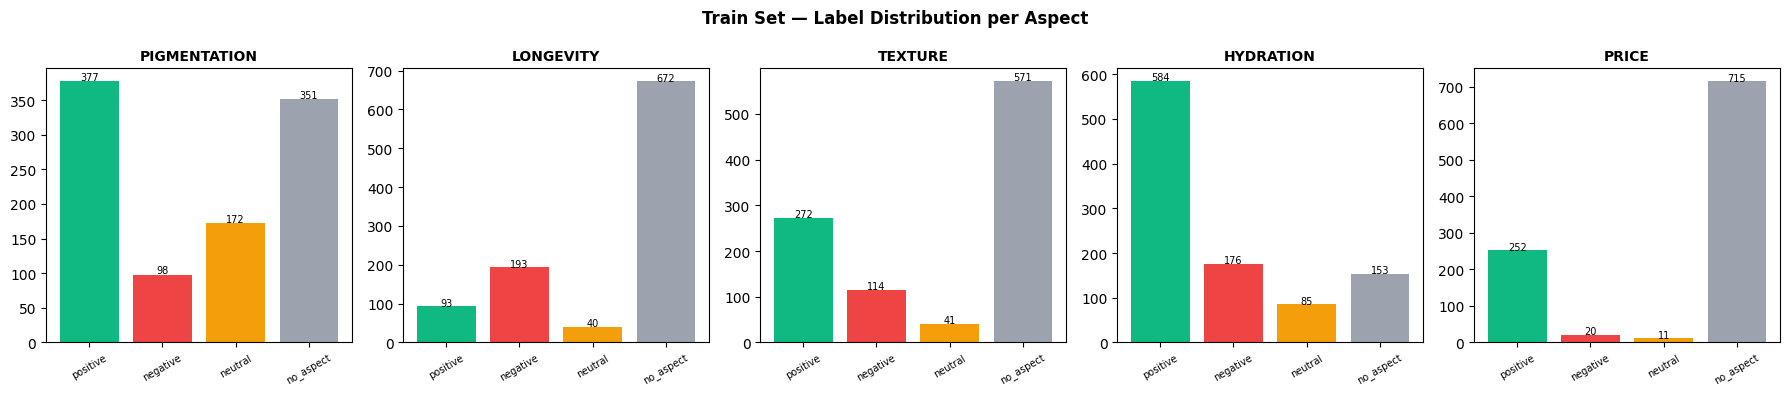

In [7]:
SENT_COLORS = {'negative': '#ef4444', 'neutral': '#f59e0b',
               'positive': '#10b981', 'no_aspect': '#9ca3af'}

fig, axes = plt.subplots(1, len(ASPECTS), figsize=(18, 4))
for ax, asp in zip(axes, ASPECTS):
    counts = train_df[asp].value_counts().reindex(
        ['positive', 'negative', 'neutral', 'no_aspect'], fill_value=0
    )
    bars = ax.bar(counts.index, counts.values,
                  color=[SENT_COLORS[l] for l in counts.index])
    ax.set_title(asp, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v), ha='center', fontsize=7)
plt.suptitle('Train Set — Label Distribution per Aspect', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Tokenizer & Dataset

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Tokenizer : {CONFIG["model_name"]}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer : indobenchmark/indobert-base-p1
Vocab size: 30,521


In [9]:
class ABSADataset(Dataset):
    """
    Multilabel ABSA dataset — wide format.

    Input : [CLS] review_text [SEP]
    labels: float tensor (15,)  — one-hot per active (aspect, sentiment) slot
    mask  : float tensor (15,)  — 1.0 for slots where aspect != no_aspect

    Flat layout: [pig_neg, pig_neu, pig_pos, lon_neg, ..., pri_pos]
    """

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 128):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        enc = self.tokenizer(
            str(row['review_text']),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        labels = torch.zeros(15, dtype=torch.float)
        mask   = torch.zeros(15, dtype=torch.float)

        for asp_idx, asp in enumerate(ASPECTS):
            val  = row[asp]
            base = asp_idx * 3
            if val != 'no_aspect':
                labels[base + SENT2ID[val]] = 1.0
                mask[base : base + 3]       = 1.0

        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels'        : labels,
            'mask'          : mask,
            'review_id'     : str(row['review_id']),
        }

In [10]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

train_ds = ABSADataset(train_df, tokenizer, CONFIG['max_length'])
val_ds   = ABSADataset(val_df,   tokenizer, CONFIG['max_length'])
test_ds  = ABSADataset(test_df,  tokenizer, CONFIG['max_length'])

print(f'Train : {len(train_ds)} reviews')
print(f'Val   : {len(val_ds)} reviews')
print(f'Test  : {len(test_ds)} reviews')

s = train_ds[0]
print(f'\nSample 0 active aspects: '
      f'{[(ASPECTS[i], SENTIMENTS[j]) for i in range(5) for j in range(3) if s["labels"][i*3+j] == 1.0]}')

Train : 998 reviews
Val   : 50 reviews
Test  : 50 reviews

Sample 0 active aspects: [('HYDRATION', 'positive')]


---
## Section 5: DataLoader

In [11]:
def collate_fn(batch):
    return {
        'input_ids'     : torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'token_type_ids': torch.stack([b['token_type_ids'] for b in batch]),
        'labels'        : torch.stack([b['labels']         for b in batch]),
        'mask'          : torch.stack([b['mask']           for b in batch]),
        'review_id'     : [b['review_id'] for b in batch],
    }

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

b = next(iter(train_loader))
print('\nBatch shapes:')
for k in ['input_ids', 'attention_mask', 'token_type_ids', 'labels', 'mask']:
    print(f'  {k:<16}: {b[k].shape}  dtype={b[k].dtype}')

Train batches: 63
Val   batches: 4
Test  batches: 4

Batch shapes:
  input_ids       : torch.Size([16, 128])  dtype=torch.int64
  attention_mask  : torch.Size([16, 128])  dtype=torch.int64
  token_type_ids  : torch.Size([16, 128])  dtype=torch.int64
  labels          : torch.Size([16, 15])  dtype=torch.float32
  mask            : torch.Size([16, 15])  dtype=torch.float32


---
## Section 6: Model Definition — CABiLSTM-IndoBERT (Partial Unfreeze)

Arsitektur CABiLSTM sama persis dengan M2. Perbedaan **hanya** pada strategi BERT:
- M2  : Seluruh BERT frozen → hanya dipakai sebagai feature extractor statis
- M2-v2: Layer 0–7 frozen, layer 8–11 trainable dengan lr kecil (2e-5) untuk domain adaptation

In [12]:
class CABiLSTMCore(nn.Module):
    """
    CABiLSTM deep implicit feature extraction layer (He et al., 2025 Section 3.3).

    Pipeline:
      1. Dual-layer BiLSTM → preserve outputs {V, F1, B1, F2, B2}
      2. MHSA on each of 5 feature groups independently
      3. Channel-wise concat {A1..A5} → Conv2d (5→1) → ReLU

    Input : x  [B, L, hidden_dim]
    Output: Co [B, L, hidden_dim]
    """

    def __init__(self, hidden_dim: int = 768, bilstm_hidden: int = 384,
                 num_heads: int = 8, conv_kernel: int = 5):
        super().__init__()

        self.bilstm1 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)
        self.bilstm2 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=0.0, batch_first=True,
        )

        pad = conv_kernel // 2
        self.conv = nn.Conv2d(in_channels=5, out_channels=1,
                              kernel_size=conv_kernel, padding=pad)

    def _split_bidirectional(self, out: torch.Tensor) -> tuple:
        """Split BiLSTM output into forward/backward, each repeated to full hidden_dim."""
        half = out.size(-1) // 2
        fwd, bwd = out[..., :half], out[..., half:]
        return torch.cat([fwd, fwd], dim=-1), torch.cat([bwd, bwd], dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Stage 1: Dual-layer BiLSTM — preserve per-layer, per-direction outputs
        out1, _ = self.bilstm1(x)
        F1, B1  = self._split_bidirectional(out1)

        out2, _ = self.bilstm2(out1)
        F2, B2  = self._split_bidirectional(out2)

        # Stage 2: MHSA on each of 5 feature groups
        attended = [self.attention(fg, fg, fg)[0] for fg in [x, F1, B1, F2, B2]]

        # Stage 3: Channel-wise concat + Conv2d + ReLU
        Ao = torch.stack(attended, dim=1)        # [B, 5, L, 768]
        Co = F.relu(self.conv(Ao).squeeze(1))    # [B, L, 768]
        return Co

In [13]:
class M2v2_CABiLSTM_IndoBERT(nn.Module):
    """
    M2-v2: CABiLSTM-IndoBERT with partial BERT fine-tuning.

    BERT freeze strategy:
      - Embeddings  : always frozen
      - Layers 0–7  : frozen  (preserve general Indonesian language knowledge)
      - Layers 8–11 : trainable (lr=2e-5, domain adaptation)
      - CABiLSTM+MLP: trainable (lr=5e-4, trained from scratch)
    """

    def __init__(self, config: dict):
        super().__init__()

        self.bert = AutoModel.from_pretrained(config['model_name'])
        self._apply_partial_freeze(config['num_unfrozen_layers'])

        hidden_dim = self.bert.config.hidden_size  # 768

        self.cabilstm = CABiLSTMCore(
            hidden_dim    = hidden_dim,
            bilstm_hidden = config['bilstm_hidden'],
            num_heads     = config['attn_heads'],
            conv_kernel   = config['conv_kernel'],
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim,             config['mlp_hidden_1']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_1'], config['mlp_hidden_2']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_2'], config['num_outputs']),
        )
        self._init_classifier_weights()

    def _apply_partial_freeze(self, num_unfrozen: int):
        """Freeze embeddings + bottom layers; keep top `num_unfrozen` layers trainable."""
        n_total  = len(self.bert.encoder.layer)   # 12
        n_frozen = n_total - num_unfrozen          # 8

        for p in self.bert.embeddings.parameters():
            p.requires_grad = False

        for i, layer in enumerate(self.bert.encoder.layer):
            for p in layer.parameters():
                p.requires_grad = (i >= n_frozen)

        print(f'BERT freeze config: embeddings + layers 0–{n_frozen-1} frozen | '
              f'layers {n_frozen}–{n_total-1} trainable')

    def _init_classifier_weights(self):
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def get_param_groups(self, lr_bert: float, lr_cabilstm: float,
                         weight_decay: float) -> list:
        """
        Differential learning rate parameter groups:
          - Group 0/1: BERT unfrozen layers (lr_bert)
          - Group 2/3: CABiLSTM + MLP      (lr_cabilstm)
        Each split into decay / no-decay for proper AdamW behaviour.
        """
        no_decay    = {'bias', 'LayerNorm.weight'}
        bert_decay,  bert_nodecay  = [], []
        other_decay, other_nodecay = [], []

        for name, param in self.named_parameters():
            if not param.requires_grad:
                continue
            is_bert   = name.startswith('bert.')
            is_nodecay = any(nd in name for nd in no_decay)

            if is_bert:
                (bert_nodecay if is_nodecay else bert_decay).append(param)
            else:
                (other_nodecay if is_nodecay else other_decay).append(param)

        return [
            {'params': bert_decay,   'lr': lr_bert,    'weight_decay': weight_decay},
            {'params': bert_nodecay, 'lr': lr_bert,    'weight_decay': 0.0},
            {'params': other_decay,  'lr': lr_cabilstm,'weight_decay': weight_decay},
            {'params': other_nodecay,'lr': lr_cabilstm,'weight_decay': 0.0},
        ]

    def forward(self, input_ids, attention_mask, token_type_ids):
        # BERT (partial frozen) → word vectors
        V = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        ).last_hidden_state                             # [B, L, 768]

        # CABiLSTM
        Co = self.cabilstm(V)                          # [B, L, 768]

        # Masked mean pooling
        mask_exp = attention_mask.unsqueeze(-1).float() # [B, L, 1]
        M = (Co * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1)
        # [B, 768]

        return self.classifier(M)                      # [B, 15]

In [14]:
model = M2v2_CABiLSTM_IndoBERT(CONFIG).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
bert_tr   = sum(p.numel() for n, p in model.named_parameters()
                if p.requires_grad and n.startswith('bert.'))
other_tr  = trainable - bert_tr

print(f'Total params          : {total:>14,}')
print(f'Trainable params      : {trainable:>14,}  ({100*trainable/total:.1f}%)')
print(f'  BERT unfrozen layers: {bert_tr:>14,}  ({100*bert_tr/trainable:.1f}% of trainable)')
print(f'  CABiLSTM + MLP      : {other_tr:>14,}  ({100*other_tr/trainable:.1f}% of trainable)')
print(f'Frozen params         : {total-trainable:>14,}  ({100*(total-trainable)/total:.1f}%)')

# Forward pass sanity check
model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))
    logits = model(sample['input_ids'].to(device),
                   sample['attention_mask'].to(device),
                   sample['token_type_ids'].to(device))
    print(f'\nOutput shape : {logits.shape}  (expected: [{CONFIG["batch_size"]}, 15])')
    print(f'Any NaN      : {torch.isnan(logits).any().item()}')

if torch.cuda.is_available():
    print(f'GPU allocated: {torch.cuda.memory_allocated(device)/1e9:.2f} GB')
    torch.cuda.empty_cache()

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BERT freeze config: embeddings + layers 0–7 frozen | layers 8–11 trainable
Total params          :    135,213,965
Trainable params      :     39,714,701  (29.4%)
  BERT unfrozen layers:     28,942,080  (72.9% of trainable)
  CABiLSTM + MLP      :     10,772,621  (27.1% of trainable)
Frozen params         :     95,499,264  (70.6%)

Output shape : torch.Size([16, 15])  (expected: [16, 15])
Any NaN      : False
GPU allocated: 0.55 GB


---
## Section 7: Loss Function, Optimizer & Scheduler

In [15]:
def masked_bce_loss(logits: torch.Tensor,
                    labels: torch.Tensor,
                    mask  : torch.Tensor) -> torch.Tensor:
    """
    BCEWithLogitsLoss with no_aspect masking.

    Only slots where mask==1 (aspect present) contribute to loss.

    Args:
        logits : (B, 15) raw model output
        labels : (B, 15) one-hot float targets
        mask   : (B, 15) 1.0 for active slots, 0.0 for no_aspect
    Returns:
        scalar mean loss over active slots
    """
    loss = F.binary_cross_entropy_with_logits(logits, labels, reduction='none')
    return (loss * mask).sum() / mask.sum().clamp(min=1.0)

In [16]:
# Differential LR optimizer: BERT top layers vs CABiLSTM + MLP
param_groups = model.get_param_groups(
    lr_bert     = CONFIG['lr_bert'],
    lr_cabilstm = CONFIG['lr_cabilstm'],
    weight_decay= CONFIG['weight_decay'],
)
optimizer = torch.optim.AdamW(param_groups)

total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(CONFIG['warmup_ratio'] * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print(f'Optimizer    : AdamW — differential LR')
print(f'  BERT unfrozen layers: lr={CONFIG["lr_bert"]}')
print(f'  CABiLSTM + MLP      : lr={CONFIG["lr_cabilstm"]}')
print(f'Total steps  : {total_steps}')
print(f'Warmup steps : {warmup_steps}')
print(f'Loss         : BCEWithLogitsLoss (masked)')

# Verify param group sizes
print(f'\nParam groups:')
labels_pg = ['BERT decay', 'BERT no-decay', 'Other decay', 'Other no-decay']
for label, pg in zip(labels_pg, param_groups):
    n = sum(p.numel() for p in pg['params'])
    print(f'  {label:<20}: lr={pg["lr"]:.0e}  wd={pg["weight_decay"]}  params={n:,}')

Optimizer    : AdamW — differential LR
  BERT unfrozen layers: lr=2e-05
  CABiLSTM + MLP      : lr=0.0005
Total steps  : 630
Warmup steps : 63
Loss         : BCEWithLogitsLoss (masked)

Param groups:
  BERT decay          : lr=0e+00  wd=0.01  params=28,901,376
  BERT no-decay       : lr=0e+00  wd=0.0  params=40,704
  Other decay         : lr=0e+00  wd=0.01  params=10,755,709
  Other no-decay      : lr=0e+00  wd=0.0  params=16,912


---
## Section 8: Metric Helpers

In [17]:
def preds_from_logits(logits: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """(B,15) logits → (B,5) predicted sentiment index; -1 for no_aspect slots."""
    probs    = torch.sigmoid(logits).view(-1, 5, 3)
    mask_asp = mask.view(-1, 5, 3)[:, :, 0]
    pred     = probs.argmax(dim=-1)
    pred[mask_asp == 0] = -1
    return pred.cpu().numpy()


def labels_from_tensor(labels: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """(B,15) one-hot labels → (B,5) true sentiment index; -1 for no_aspect slots."""
    lbl_3d   = labels.view(-1, 5, 3)
    mask_asp = mask.view(-1, 5, 3)[:, :, 0]
    true     = lbl_3d.argmax(dim=-1)
    true[mask_asp == 0] = -1
    return true.cpu().numpy()


def compute_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> dict:
    """Global macro metrics over all active (non -1) slots."""
    flat_t, flat_p = all_true.flatten(), all_pred.flatten()
    active = flat_t != -1
    t, p   = flat_t[active], flat_p[active]
    return {
        'macro_f1'  : f1_score(t, p, average='macro', zero_division=0),
        'macro_prec': precision_score(t, p, average='macro', zero_division=0),
        'macro_rec' : recall_score(t, p, average='macro', zero_division=0),
        'accuracy'  : accuracy_score(t, p),
    }


def compute_per_aspect_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> list:
    """Macro F1 per aspect, excluding no_aspect (-1) rows."""
    results = []
    for i, asp in enumerate(ASPECTS):
        t, p   = all_true[:, i], all_pred[:, i]
        active = t != -1
        n      = int(active.sum())
        if n > 0:
            f1   = f1_score(t[active], p[active], average='macro', zero_division=0)
            prec = precision_score(t[active], p[active], average='macro', zero_division=0)
            rec  = recall_score(t[active], p[active], average='macro', zero_division=0)
            acc  = accuracy_score(t[active], p[active])
        else:
            f1 = prec = rec = acc = 0.0
        results.append({'aspect': asp, 'f1': f1, 'precision': prec,
                        'recall': rec, 'accuracy': acc, 'n_active': n})
    return results

print('Metric helpers defined.')

Metric helpers defined.


---
## Section 9: Training & Validation Loop

In [18]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        mask           = batch['mask'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = masked_bce_loss(logits, labels, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_true.append(labels_from_tensor(labels.cpu(), mask.cpu()))
        all_pred.append(preds_from_logits(logits.detach().cpu(), mask.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        mask           = batch['mask'].to(device)

        logits     = model(input_ids, attention_mask, token_type_ids)
        total_loss += masked_bce_loss(logits, labels, mask).item()
        all_true.append(labels_from_tensor(labels.cpu(), mask.cpu()))
        all_pred.append(preds_from_logits(logits.cpu(), mask.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred), all_true, all_pred

print('Train/eval functions defined.')

Train/eval functions defined.


In [19]:
history = {'train_loss': [], 'val_loss': [],
           'train_f1'  : [], 'val_f1'  : []}

best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

print('=== Training M2-v2 — CABiLSTM-IndoBERT Partial Unfreeze ===')
for epoch in range(CONFIG['epochs']):
    t0 = time.time()

    train_loss, train_m          = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss,   val_m, _, _      = eval_epoch(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_f1'  ].append(train_m['macro_f1'])
    history['val_f1'    ].append(val_m['macro_f1'])

    print(f"Ep {epoch+1:02d}/{CONFIG['epochs']} "
          f"| TrLoss {train_loss:.4f}  ValLoss {val_loss:.4f} "
          f"| TrF1 {train_m['macro_f1']:.4f}  ValF1 {val_m['macro_f1']:.4f} "
          f"| {time.time()-t0:.1f}s")

    if val_m['macro_f1'] > best_val_f1:
        best_val_f1 = val_m['macro_f1']
        best_epoch  = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ⭐ Best model saved (ValF1={best_val_f1:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f'  🛑 Early stopping at epoch {epoch+1}')
            break

print(f'\nDone. Best epoch={best_epoch}, Best ValF1={best_val_f1:.4f}')

=== Training M2-v2 — CABiLSTM-IndoBERT Partial Unfreeze ===


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 01/10 | TrLoss 0.5412  ValLoss 0.4118 | TrF1 0.4162  ValF1 0.4798 | 19.6s
  ⭐ Best model saved (ValF1=0.4798)


Train:   0%|          | 0/63 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 07/10 | TrLoss 0.1939  ValLoss 0.4318 | TrF1 0.8396  ValF1 0.6671 | 22.9s


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 08/10 | TrLoss 0.1518  ValLoss 0.4537 | TrF1 0.8842  ValF1 0.6258 | 23.6s
  🛑 Early stopping at epoch 8

Done. Best epoch=5, Best ValF1=0.6833


---
## Section 10: Loss Convergence Plot

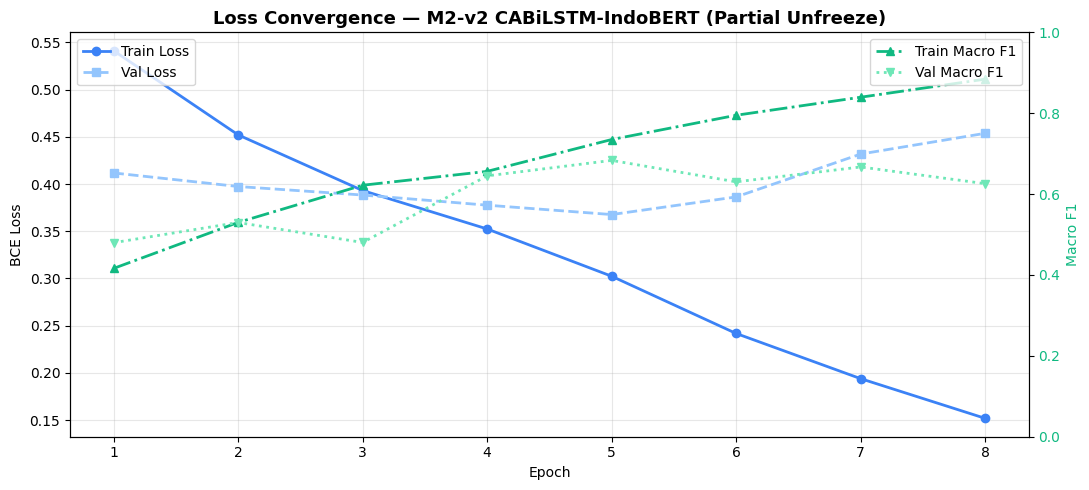

Saved: /kaggle/working/m2v2_loss_convergence.png


In [20]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(epochs_range, history['train_loss'], 'o-',  color='#3b82f6', label='Train Loss', lw=2)
ax1.plot(epochs_range, history['val_loss'],   's--', color='#93c5fd', label='Val Loss',   lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss'); ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_range, history['train_f1'], '^-.',  color='#10b981', label='Train Macro F1', lw=2)
ax2.plot(epochs_range, history['val_f1'],   'v:',   color='#6ee7b7', label='Val Macro F1',   lw=2)
ax2.set_ylabel('Macro F1', color='#10b981')
ax2.tick_params(axis='y', labelcolor='#10b981')
ax2.set_ylim([0, 1]); ax2.legend(loc='upper right')

plt.title('Loss Convergence — M2-v2 CABiLSTM-IndoBERT (Partial Unfreeze)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOSS_PLOT_PATH}')

---
## Section 11: Evaluasi Test Set

In [21]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
print(f'Loaded best model from epoch {best_epoch}')

test_loss, test_m, test_true, test_pred = eval_epoch(model, test_loader, device)

print('\n' + '='*65)
print('TEST SET RESULTS — M2-v2 CABiLSTM-IndoBERT (Proposal Section 2.2.4)')
print('='*65)
print(f'Test BCE Loss          : {test_loss:.4f}')
print(f'Accuracy  (Pers. 2.15) : {test_m["accuracy"]:.4f}')
print(f'Macro Precision        : {test_m["macro_prec"]:.4f}')
print(f'Macro Recall           : {test_m["macro_rec"]:.4f}')
print(f'Macro F1   (Pers. 2.14): {test_m["macro_f1"]:.4f}')

Loaded best model from epoch 5


Eval :   0%|          | 0/4 [00:00<?, ?it/s]


TEST SET RESULTS — M2-v2 CABiLSTM-IndoBERT (Proposal Section 2.2.4)
Test BCE Loss          : 0.2970
Accuracy  (Pers. 2.15) : 0.7377
Macro Precision        : 0.6583
Macro Recall           : 0.6131
Macro F1   (Pers. 2.14): 0.6295


In [22]:
per_asp = compute_per_aspect_metrics(test_true, test_pred)
avg_f1  = float(np.mean([r['f1'] for r in per_asp]))

print('\nPer-Aspect Results (sentiment-only, no_aspect excluded):')
print(f'{"Aspect":<14} {"F1":>8} {"Prec":>8} {"Rec":>8} {"Acc":>8} {"N":>5}')
print('-'*55)
for r in per_asp:
    print(f'{r["aspect"]:<14} {r["f1"]:>8.4f} {r["precision"]:>8.4f} '
          f'{r["recall"]:>8.4f} {r["accuracy"]:>8.4f} {r["n_active"]:>5}')
print('-'*55)
print(f'{"MACRO AVG":<14} {avg_f1:>8.4f}')


Per-Aspect Results (sentiment-only, no_aspect excluded):
Aspect               F1     Prec      Rec      Acc     N
-------------------------------------------------------
PIGMENTATION     0.6098   0.6038   0.6279   0.7353    34
LONGEVITY        0.4745   0.4583   0.5093   0.7143    14
TEXTURE          0.3914   0.4444   0.4029   0.6667    21
HYDRATION        0.4103   0.4238   0.4111   0.7143    42
PRICE            1.0000   1.0000   1.0000   1.0000    11
-------------------------------------------------------
MACRO AVG        0.5772


Global Classification Report (active slots, 3-class sentiment):
              precision    recall  f1-score   support

    negative     0.6500    0.4643    0.5417        28
     neutral     0.5385    0.5000    0.5185        14
    positive     0.7865    0.8750    0.8284        80

    accuracy                         0.7377       122
   macro avg     0.6583    0.6131    0.6295       122
weighted avg     0.7267    0.7377    0.7270       122



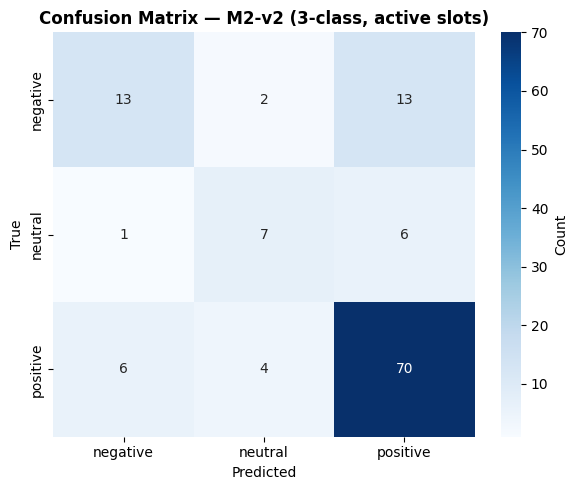

Saved: /kaggle/working/m2v2_confusion_matrix.png


In [23]:
flat_true   = test_true.flatten()
flat_pred   = test_pred.flatten()
active_mask = flat_true != -1

print('Global Classification Report (active slots, 3-class sentiment):')
print(classification_report(
    flat_true[active_mask], flat_pred[active_mask],
    target_names=SENTIMENTS, digits=4, zero_division=0
))

cm = confusion_matrix(flat_true[active_mask], flat_pred[active_mask], labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SENTIMENTS, yticklabels=SENTIMENTS,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — M2-v2 (3-class, active slots)', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CM_PLOT_PATH}')

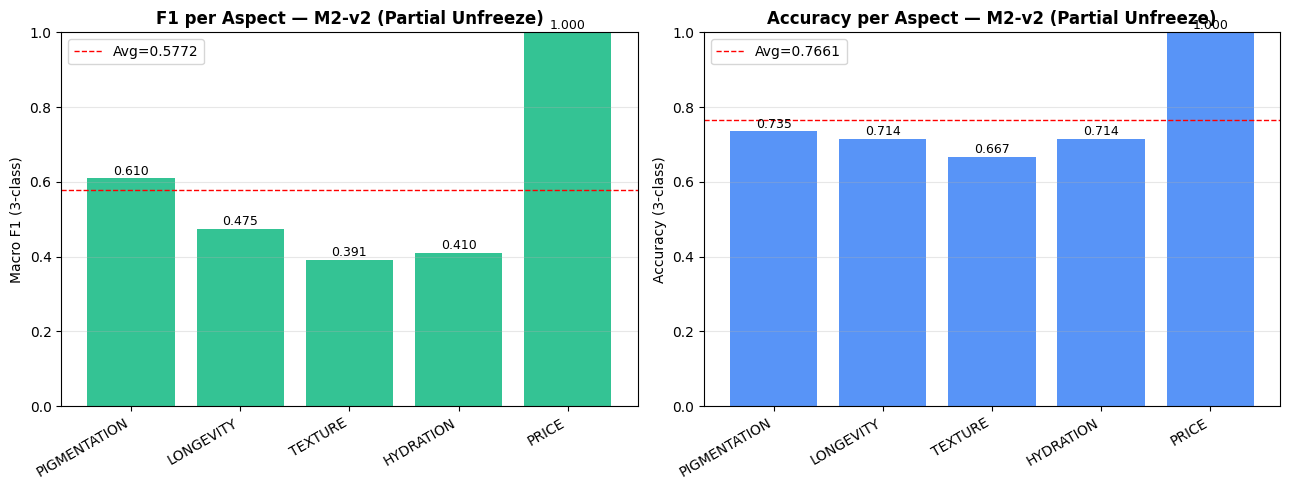

Saved: /kaggle/working/m2v2_per_aspect_results.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(ASPECTS))

for ax, vals, ylabel, color in zip(
        axes,
        [[r['f1'] for r in per_asp], [r['accuracy'] for r in per_asp]],
        ['Macro F1 (3-class)', 'Accuracy (3-class)'],
        ['#10b981', '#3b82f6']):
    bars = ax.bar(x, vals, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ASPECTS, rotation=30, ha='right')
    ax.set_ylabel(ylabel); ax.set_ylim([0, 1])
    ax.axhline(np.mean(vals), color='red', linestyle='--', linewidth=1,
               label=f'Avg={np.mean(vals):.4f}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

axes[0].set_title('F1 per Aspect — M2-v2 (Partial Unfreeze)', fontweight='bold')
axes[1].set_title('Accuracy per Aspect — M2-v2 (Partial Unfreeze)', fontweight='bold')
plt.tight_layout()
plt.savefig(PERASPECT_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PERASPECT_PLOT_PATH}')

---
## Section 12: Hamming Loss (Proposal Persamaan 2.16)

In [25]:
D = test_true.shape[0]   # reviews
L = test_true.shape[1]   # aspects = 5

mismatches   = (test_true != test_pred).sum()
hamming_loss = mismatches / (D * L)

print('='*55)
print('HAMMING LOSS (Proposal Persamaan 2.16)')
print('='*55)
print(f'|D| (reviews) : {D}')
print(f'|L| (aspects) : {L}')
print(f'Mismatches    : {mismatches}')
print(f'Hamming Loss  : {mismatches}/{D*L} = {hamming_loss:.4f}')
print(f'Hamming Acc   : {1-hamming_loss:.4f}')

print('\nPer-Aspect Hamming Loss:')
print(f'{"Aspect":<14} {"Mismatch":>10} {"HL":>8} {"HA":>8}')
print('-'*44)
per_asp_hl = []
for i, asp in enumerate(ASPECTS):
    mm = int((test_true[:, i] != test_pred[:, i]).sum())
    hl = mm / D
    per_asp_hl.append(hl)
    print(f'{asp:<14} {mm:>10} {hl:>8.4f} {1-hl:>8.4f}')
print('-'*44)
print(f'{"MACRO AVG":<14} {"":>10} {np.mean(per_asp_hl):>8.4f} {1-np.mean(per_asp_hl):>8.4f}')

HAMMING LOSS (Proposal Persamaan 2.16)
|D| (reviews) : 50
|L| (aspects) : 5
Mismatches    : 32
Hamming Loss  : 32/250 = 0.1280
Hamming Acc   : 0.8720

Per-Aspect Hamming Loss:
Aspect           Mismatch       HL       HA
--------------------------------------------
PIGMENTATION            9   0.1800   0.8200
LONGEVITY               4   0.0800   0.9200
TEXTURE                 7   0.1400   0.8600
HYDRATION              12   0.2400   0.7600
PRICE                   0   0.0000   1.0000
--------------------------------------------
MACRO AVG                   0.1280   0.8720


---
## Section 13: Save Predictions & Metrics

In [26]:
# ── Predictions CSV ───────────────────────────────────────────────────────────
pred_rows = [
    {
        'review_id' : test_df.iloc[i]['review_id'],
        'aspect'    : asp,
        'true_label': ID2SENT.get(test_true[i, j], 'no_aspect'),
        'pred_label': ID2SENT.get(test_pred[i, j], 'no_aspect'),
        'correct'   : test_true[i, j] == test_pred[i, j],
    }
    for i in range(len(test_df))
    for j, asp in enumerate(ASPECTS)
]
pd.DataFrame(pred_rows).to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}')

# ── Metrics JSON ──────────────────────────────────────────────────────────────
metrics_out = {
    'model'           : 'M2v2_CABiLSTM_IndoBERT_PartialUnfreeze_BCE',
    'config'          : CONFIG,
    'best_epoch'      : int(best_epoch),
    'best_val_f1'     : float(best_val_f1),
    'test_loss'       : float(test_loss),
    'test_accuracy'   : float(test_m['accuracy']),
    'test_macro_f1'   : float(test_m['macro_f1']),
    'test_macro_prec' : float(test_m['macro_prec']),
    'test_macro_rec'  : float(test_m['macro_rec']),
    'per_aspect'      : per_asp,
    'avg_per_aspect_f1': float(avg_f1),
    'hamming_loss'    : {
        'formula'          : 'Proposal Persamaan 2.16',
        'D_reviews'        : int(D),
        'L_aspects'        : int(L),
        'overall'          : float(hamming_loss),
        'hamming_accuracy' : float(1 - hamming_loss),
        'per_aspect'       : {asp: float(hl) for asp, hl in zip(ASPECTS, per_asp_hl)},
    },
    'history': {k: [float(v) for v in vs] for k, vs in history.items()},
}
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_out, f, indent=2, default=str)
print(f'Metrics  saved: {METRICS_PATH}')

print('\n' + '='*55)
print(f'✅ M2-v2 complete — Test Macro F1: {test_m["macro_f1"]:.4f}')
print('='*55)

Predictions saved: /kaggle/working/m2v2_predictions.csv
Metrics  saved: /kaggle/working/m2v2_metrics.json

✅ M2-v2 complete — Test Macro F1: 0.6295
